In [1]:
import json
from collections import defaultdict
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from tqdm.notebook import tqdm

In [2]:
with open("./v1.5/dev/archehr-qa_key.json") as f:
    key = json.load(f)


tree = ET.parse("./v1.5/dev/archehr-qa.xml")
root = tree.getroot()

data = []
for case in root.findall("case"):
    case_id = case.get('id')
    question = case.findtext("clinician_question", default="").strip()
    sentences = [
        {
            'sentence_id': sentence.get('id'),
            'text': sentence.text.strip()
        }
        for sentence in case.find("note_excerpt_sentences")
    ]
    item = {
        'case_id': case_id,
        'excerpt_sentences': sentences
    }
    data.append(item)

df1 = pd.DataFrame(data)
df2 = pd.DataFrame(key)
combined = df1.merge(df2[['case_id', 'clinician_answer_sentences']], on='case_id').to_dict(orient='records')

In [3]:
# Load the model
model = SentenceTransformer("Qwen/Qwen3-Embedding-8B", device='mps')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [6]:
score_dict = {}

for case in tqdm(combined):
    answer_sentences = [a['text'] for a in case['clinician_answer_sentences']]
    excerpt_sentences = [s['text'] for s in case['excerpt_sentences']]

    answer_embs = model.encode(answer_sentences)
    excerpt_embs = model.encode(excerpt_sentences)

    scores = model.similarity(answer_embs, excerpt_embs).numpy()
    score_dict[case['case_id']] = scores

  0%|          | 0/20 [00:00<?, ?it/s]

In [7]:
submission_dict = {}

for threshold in tqdm(np.arange(0, 1.05, 0.05)):
    submission = []
    for case in combined:
        answer_ids = [a['id'] for a in case['clinician_answer_sentences']]
        excerpt_ids = [s['sentence_id'] for s in case['excerpt_sentences']]
        scores = score_dict[case['case_id']]
        
        # Group evidence by answer
        grouped = defaultdict(list)
        for ans_idx, ev_idx in np.argwhere(scores > threshold):
            grouped[ans_idx].append(excerpt_ids[ev_idx])
        
        # Convert to desired format
        predictions = [{"answer_id": answer_ids[ans_idx], "evidence_id": evs} 
                  for ans_idx, evs in grouped.items()]
        
        item = {'case_id': case['case_id'], 'prediction': predictions}
        submission.append(item)

    submission_dict[threshold] = submission

  0%|          | 0/21 [00:00<?, ?it/s]

In [8]:
from scoring_subtask_4 import compute_alignment_scores, get_leaderboard, load_key

key_map = load_key("./v1.5/dev/archehr-qa_key.json")

overalls = []
thresholds = []

for t, s in tqdm(submission_dict.items()):
    scores = compute_alignment_scores(s, key_map)
    leaderboard = get_leaderboard(scores)

    thresholds.append(t)
    overalls.append(leaderboard['overall_score'])

  0%|          | 0/21 [00:00<?, ?it/s]

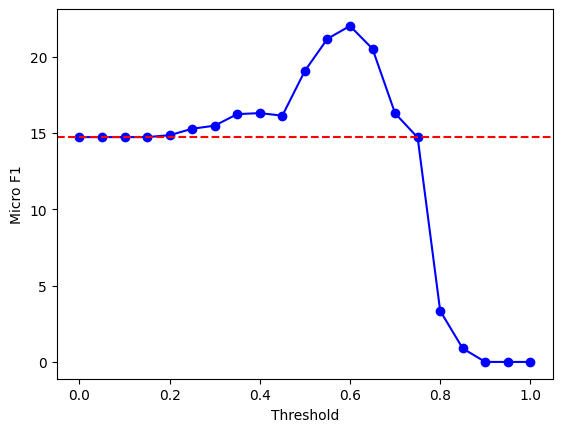

In [9]:
import matplotlib.pyplot as plt

x = thresholds
y = overalls

plt.plot(x, y, marker='o', linestyle='-', color='b')
plt.axhline(y=14.729, linestyle='--', color='r')
plt.xlabel("Threshold")
plt.ylabel("Micro F1")
plt.show()

In [11]:
dict(zip(thresholds, overalls))

{np.float64(0.0): 14.729370008873113,
 np.float64(0.05): 14.729370008873113,
 np.float64(0.1): 14.729370008873113,
 np.float64(0.15000000000000002): 14.729370008873113,
 np.float64(0.2): 14.854586129753915,
 np.float64(0.25): 15.27713088029809,
 np.float64(0.30000000000000004): 15.480519480519481,
 np.float64(0.35000000000000003): 16.236162361623617,
 np.float64(0.4): 16.300940438871475,
 np.float64(0.45): 16.13588110403397,
 np.float64(0.5): 19.07433380084152,
 np.float64(0.55): 21.172022684310022,
 np.float64(0.6000000000000001): 22.01405152224824,
 np.float64(0.65): 20.512820512820515,
 np.float64(0.7000000000000001): 16.286644951140065,
 np.float64(0.75): 14.705882352941178,
 np.float64(0.8): 3.3472803347280338,
 np.float64(0.8500000000000001): 0.8849557522123894,
 np.float64(0.9): 0.0,
 np.float64(0.9500000000000001): 0.0,
 np.float64(1.0): 0.0}

In [16]:
scores = compute_alignment_scores(submission_dict[thresholds[12]], key_map)
leaderboard = get_leaderboard(scores)
leaderboard

{'micro_precision': 22.815533980582526,
 'micro_recall': 21.266968325791854,
 'micro_f1': 22.01405152224824,
 'macro_precision': np.float64(30.746362985140074),
 'macro_recall': np.float64(26.71895799213574),
 'macro_f1': np.float64(26.18637900864067),
 'overall_score': 22.01405152224824}

In [9]:
mock_submission = []
for case in combined:
    case_id = case['case_id']
    answer_ids = [a['id'] for a in case['clinician_answer_sentences']]
    excerpt_ids = [s['sentence_id'] for s in case['excerpt_sentences']]

    mock_item = {'case_id': case_id, 'prediction':[{'answer_id': i, 'evidence_id': excerpt_ids} for i in answer_ids]}
    mock_submission.append(mock_item)

In [10]:
scores = compute_alignment_scores(mock_submission, key_map)
leaderboard = get_leaderboard(scores)
leaderboard

{'micro_precision': 8.165272995573044,
 'micro_recall': 75.1131221719457,
 'micro_f1': 14.729370008873113,
 'macro_precision': np.float64(9.055527763193668),
 'macro_recall': np.float64(76.32569614954525),
 'macro_f1': np.float64(15.944239627510786),
 'overall_score': 14.729370008873113}

In [11]:
mock_submission = []
for case in combined:
    case_id = case['case_id']
    answer_ids = [a['id'] for a in case['clinician_answer_sentences']]
    excerpt_ids = [s['sentence_id'] for s in case['excerpt_sentences']]

    mock_item = {'case_id': case_id, 'prediction':[{'answer_id': i, 'evidence_id': []} for i in answer_ids]}
    mock_submission.append(mock_item)

In [12]:
scores = compute_alignment_scores(mock_submission, key_map)
leaderboard = get_leaderboard(scores)
leaderboard

{'micro_precision': 0.0,
 'micro_recall': 0.0,
 'micro_f1': 0.0,
 'macro_precision': np.float64(0.0),
 'macro_recall': np.float64(0.0),
 'macro_f1': np.float64(0.0),
 'overall_score': 0.0}

# Test Set 2026 Submission

In [2]:
with open("./v1.5/test-2026/archehr-qa_key.json") as f:
    key = json.load(f)


tree = ET.parse("./v1.5/test-2026/archehr-qa.xml")
root = tree.getroot()

data = []
for case in root.findall("case"):
    case_id = case.get('id')
    question = case.findtext("clinician_question", default="").strip()
    sentences = [
        {
            'sentence_id': sentence.get('id'),
            'text': sentence.text.strip()
        }
        for sentence in case.find("note_excerpt_sentences")
    ]
    item = {
        'case_id': case_id,
        'excerpt_sentences': sentences
    }
    data.append(item)

df1 = pd.DataFrame(data)
df2 = pd.DataFrame(key)
combined = df1.merge(df2[['case_id', 'clinician_answer_sentences']], on='case_id').to_dict(orient='records')

In [3]:
# Load the model
model = SentenceTransformer("Qwen/Qwen3-Embedding-8B", device='mps')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [4]:
score_dict = {}

for case in tqdm(combined):
    answer_sentences = [a['text'] for a in case['clinician_answer_sentences']]
    excerpt_sentences = [s['text'] for s in case['excerpt_sentences']]

    answer_embs = model.encode(answer_sentences)
    excerpt_embs = model.encode(excerpt_sentences)

    scores = model.similarity(answer_embs, excerpt_embs).numpy()
    score_dict[case['case_id']] = scores

  0%|          | 0/47 [00:00<?, ?it/s]

In [5]:
submission = []
for case in combined:
    answer_ids = [a['id'] for a in case['clinician_answer_sentences']]
    excerpt_ids = [s['sentence_id'] for s in case['excerpt_sentences']]
    scores = score_dict[case['case_id']]
    
    # Group evidence by answer
    grouped = defaultdict(list)
    for ans_idx, ev_idx in np.argwhere(scores > 0.6):
        grouped[ans_idx].append(excerpt_ids[ev_idx])
    
    # Convert to desired format
    predictions = [{"answer_id": answer_ids[ans_idx], "evidence_id": evs} 
              for ans_idx, evs in grouped.items()]
    
    item = {'case_id': case['case_id'], 'prediction': predictions}
    submission.append(item)

In [7]:
with open("./qwen_emb_submission/submission2026.json", 'w') as f:
    json.dump(submission, f)

# Test Set Submission

In [2]:
with open("./v1.5/test/archehr-qa_key.json") as f:
    key = json.load(f)


tree = ET.parse("./v1.5/test/archehr-qa.xml")
root = tree.getroot()

data = []
for case in root.findall("case"):
    case_id = case.get('id')
    question = case.findtext("clinician_question", default="").strip()
    sentences = [
        {
            'sentence_id': sentence.get('id'),
            'text': sentence.text.strip()
        }
        for sentence in case.find("note_excerpt_sentences")
    ]
    item = {
        'case_id': case_id,
        'excerpt_sentences': sentences
    }
    data.append(item)

df1 = pd.DataFrame(data)
df2 = pd.DataFrame(key)
combined = df1.merge(df2[['case_id', 'clinician_answer_sentences']], on='case_id').to_dict(orient='records')

In [3]:
# Load the model
model = SentenceTransformer("Qwen/Qwen3-Embedding-8B", device='mps')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [4]:
score_dict = {}

for case in tqdm(combined):
    answer_sentences = [a['text'] for a in case['clinician_answer_sentences']]
    excerpt_sentences = [s['text'] for s in case['excerpt_sentences']]

    answer_embs = model.encode(answer_sentences)
    excerpt_embs = model.encode(excerpt_sentences)

    scores = model.similarity(answer_embs, excerpt_embs).numpy()
    score_dict[case['case_id']] = scores

  0%|          | 0/100 [00:00<?, ?it/s]

In [5]:
submission = []
for case in combined:
    answer_ids = [a['id'] for a in case['clinician_answer_sentences']]
    excerpt_ids = [s['sentence_id'] for s in case['excerpt_sentences']]
    scores = score_dict[case['case_id']]
    
    # Group evidence by answer
    grouped = defaultdict(list)
    for ans_idx, ev_idx in np.argwhere(scores > 0.6):
        grouped[ans_idx].append(excerpt_ids[ev_idx])
    
    # Convert to desired format
    predictions = [{"answer_id": answer_ids[ans_idx], "evidence_id": evs} 
              for ans_idx, evs in grouped.items()]
    
    item = {'case_id': case['case_id'], 'prediction': predictions}
    submission.append(item)

In [6]:
with open("./qwen_emb_submission/submission_test.json", 'w') as f:
    json.dump(submission, f)

In [10]:
with open("./qwen_emb_submission/submission_test.json") as f:
    s1 = json.load(f)
with open("./qwen_emb_submission/submission2026.json") as f:
    s2 = json.load(f)
with open("./qwen_emb_submission/submission.json", 'w') as f:
    json.dump(s1 + s2, f)